# Zadanie domowe

W przypadku obrazów w odcieniach szarości pojedynczy piksel z zakresu [0; 255] reprezentowany jest jako 8-bitowa liczba bez znaku.
Pewnym rozszerzeniem analizy sposobu reprezentacji obrazu może być następujący eksperyment.
Załóżmy, że z każdego z 8 bitów możemy stworzyć pojedynczy obraz binarny (ang. _bit-plane slicing_).
Dla obrazka _100zloty.jpg_ (https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/100zloty.jpg) stwórz 8 obrazów, z których każdy powinien zawierać jedną płaszczyznę bitową.
Podpowiedź $-$ warto sprawdzić, jak realizuje się bitowe operacje logiczne.
Zastosowanie takiej dekompozycji obrazu pozwala na analizę ,,ważności'' poszczególnych bitów.
Jest to użyteczne w kwantyzacji, ale także w kompresji.

W drugim etapie zadania proszę spróbować odtworzyć obraz oryginalny z mniejszej liczby obrazów binarnych.
Warto zacząć od dwóch najbardziej znaczących bitów, a później dodawać kolejne.
Należy utworzyć co najmniej trzy wersje zrekonstruowanych obrazów.
Podpowiedź $-$ rekonstrukcja obrazu to mnożenie przez odpowiednią potęgę liczby 2 (przesunięcie bitowe) oraz dodawanie.

In [8]:
import cv2
import os
import requests
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/'
fileName = '100zloty.jpg'
if not os.path.exists(fileName) :
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

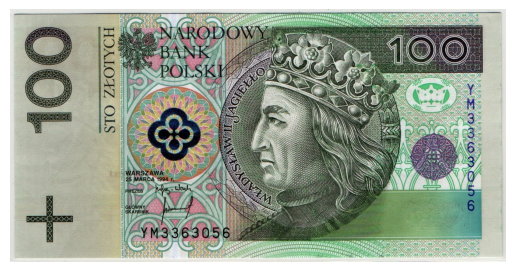

In [9]:
note = cv2.imread(fileName)

plt.imshow(note)
plt.axis("off")
plt.show()

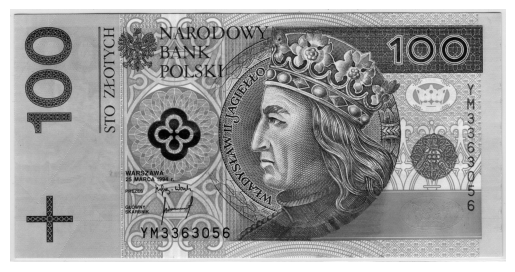

In [10]:
note_gray = cv2.cvtColor(note, cv2.COLOR_BGR2GRAY)
plt.imshow(note_gray, cmap='gray')
plt.axis("off")
plt.show()

In [11]:
BITS = 8

bit_plane_slices = []
for i in range(BITS):
    bit_plane = cv2.bitwise_and(note_gray, 1 << i)
    bit_plane_slices.append(bit_plane)

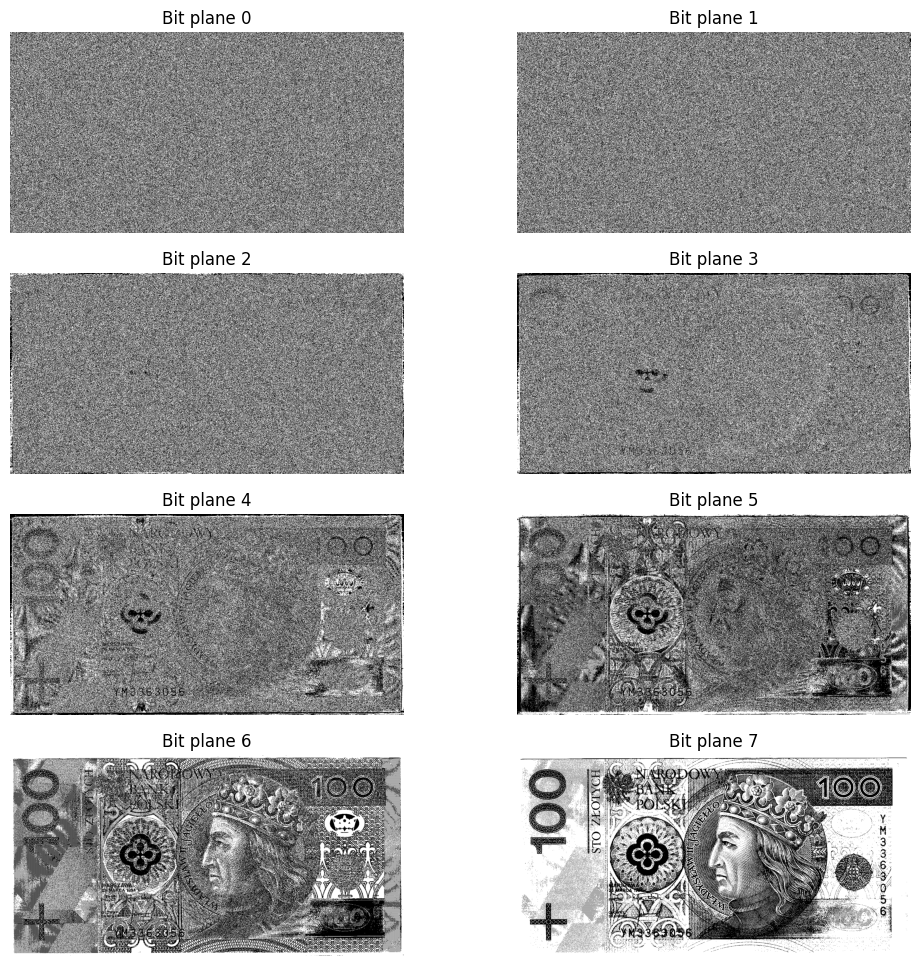

In [12]:
f, axs = plt.subplots(4, 2, figsize=(12, 12))
for i in range(4):
    axs[i, 0].imshow(bit_plane_slices[i * 2], cmap="gray")
    axs[i, 0].axis("off")
    axs[i, 0].set_title(f"Bit plane {i * 2}")
    axs[i, 1].imshow(bit_plane_slices[i * 2 + 1], cmap="gray")
    axs[i, 1].axis("off")
    axs[i, 1].set_title(f"Bit plane {i * 2 + 1}")

In [13]:
recovered_images = [bit_plane_slices[BITS - 1].copy()]
for i in range(BITS - 1, 0, -1):
    recovered = cv2.bitwise_or(recovered_images[BITS - 1 - i], bit_plane_slices[i - 1])
    recovered_images.append(recovered)

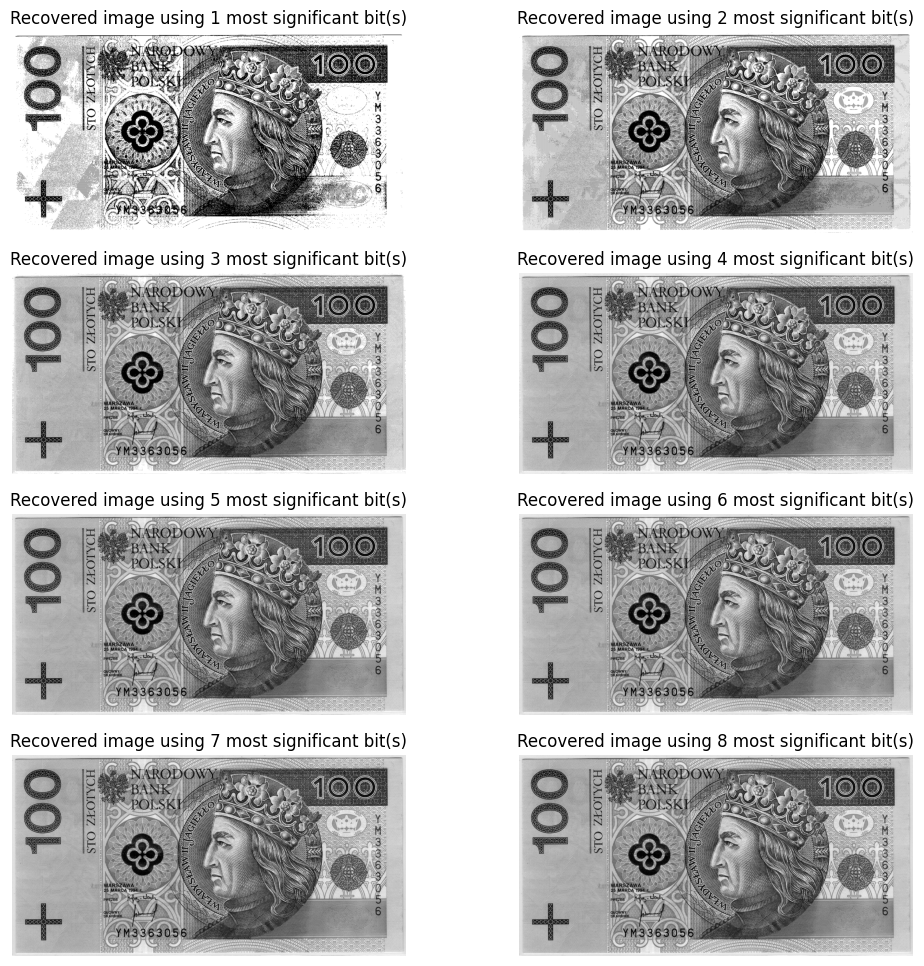

In [14]:
f, axs = plt.subplots(4, 2, figsize=(12, 12))
for i in range(4):
    axs[i, 0].imshow(recovered_images[i * 2], cmap="gray")
    axs[i, 0].axis("off")
    axs[i, 0].set_title(f"Recovered image using {i * 2 + 1} most significant bit(s)")
    axs[i, 1].imshow(recovered_images[i * 2 + 1], cmap="gray")
    axs[i, 1].axis("off")
    axs[i, 1].set_title(f"Recovered image using {i * 2 + 2} most significant bit(s)")